# Lesotho Winter Wheat Sampling Design
### FAO TCP/LES/4002 -- Leribe, Mafeteng, Berea

## Welcome

**What are we trying to achieve?**

We want to know how much land is planted with winter wheat in three Lesotho districts, and how accurate a
satellite-based wheat map is. Since visiting every field is impossible, a statistically designed sample
tells us which fields to actually visit so that a small number of field visits can represent the whole
district with a known, small margin of error.

This notebook walks through *why* the sample looks the way it does -- not just what the final numbers are
-- using the real district data, real design functions, and a few interactive demonstrations along the way.

**How to use this notebook:** run each cell in order (Shift+Enter). Cells marked *Interactive* have a
slider -- move it and watch the explanation and chart below update.


In [1]:
# Run this first.
# If running on Binder or a fresh Colab session, this installs everything needed.
!pip install geopandas rasterio rasterstats mapclassify ipywidgets -q

import os
import random
import tempfile

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from shapely.geometry import box, Point
import mapclassify
from rasterstats import zonal_stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from ipywidgets import interact, interactive_output, FloatSlider, IntSlider, HBox, VBox, Output

print("Libraries loaded.")


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Libraries loaded.


## Configuration

All paths below are relative to this repository, so the notebook runs the same way whether it's opened on
Binder, Colab (from GitHub), or locally -- no Google Drive mount required.


In [2]:
INPUT_DIR = "input_data"

DISTRICT_FILES = {
    "Leribe": {
        "wheat_raster": f"{INPUT_DIR}/Leribe/Leribe_wheat_2025.tif",
        "likelihood_raster": f"{INPUT_DIR}/Leribe/Leribe_wheat_likelihood_2025.tif",
        "slope": f"{INPUT_DIR}/Leribe/Leribe_DEM_2025.tif",
    },
    "Mafeteng": {
        "wheat_raster": f"{INPUT_DIR}/Mafeteng/Mafeteng_wheat_2025.tif",
        "likelihood_raster": f"{INPUT_DIR}/Mafeteng/Mafeteng_wheat_likelihood_2025.tif",
        "slope": f"{INPUT_DIR}/Mafeteng/Mafeteng_DEM_2025.tif",
    },
    "Berea": {
        "wheat_raster": f"{INPUT_DIR}/Berea/Berea_wheat_2025.tif",
        "likelihood_raster": f"{INPUT_DIR}/Berea/Berea_wheat_likelihood_2025.tif",
        "slope": f"{INPUT_DIR}/Berea/Berea_DEM_2025.tif",
    },
}

AEZ_SHAPEFILE_PATH = f"{INPUT_DIR}/vectors/Lesotho_AEZ_vectors_clean.shp"
AEZ_FIELD = "CLASS"
DISTRICT_BOUNDARY_PATH = f"{INPUT_DIR}/vectors/LSO_adm1.shp"
DISTRICT_NAME_FIELD = "NAME_1"

GRID_SIZE_M = 2000
GRID_CRS = "EPSG:32735"
MIN_WHEAT_INTENSITY_PCT = 0.2
N_INTENSITY_CLASSES = 3
MAX_SLOPE_PCT = 30
MAX_SSU_PER_PSU = 15
DEFAULT_UI_BY_CLASS = {1: 0.70, 2: 0.80, 3: 0.90}

DISTRICT_SSU_BUDGET = {"Leribe": 612, "Mafeteng": 468, "Berea": 536}
C1_C2_BY_DISTRICT = {
    "Leribe": {"c1": 90.0, "c2": 10.0},
    "Mafeteng": {"c1": 90.0, "c2": 10.0},
    "Berea": {"c1": 90.0, "c2": 10.0},
}

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DISTRICT = "Leribe"   # change this to explore Mafeteng or Berea throughout the notebook

print("Configuration loaded. Working district:", DISTRICT)


Configuration loaded. Working district: Leribe


## Core functions

The functions below implement each stage of the design. They're grouped here so the rest of the notebook
can focus on *why* each stage matters rather than code mechanics -- but nothing here is hidden or
simplified; this is the same logic used to produce the approved design document.


In [3]:
def reproject_raster(src_path, dst_crs, dst_path=None):
    # Reprojects a raster to the metric grid CRS. Float rasters get a NaN nodata value;
    # integer rasters (like the binary wheat mask) fall back to 255.
    if dst_path is None:
        dst_path = tempfile.NamedTemporaryFile(suffix=".tif", delete=False).name
    with rasterio.open(src_path) as src:
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds
        )
        kwargs = src.meta.copy()
        for k in ("blockxsize", "blockysize", "tiled"):
            kwargs.pop(k, None)
        if np.issubdtype(np.dtype(src.dtypes[0]), np.floating):
            nodata_val = np.nan
        else:
            nodata_val = src.nodata if src.nodata is not None else 255
        kwargs.update({"crs": dst_crs, "transform": transform, "width": width,
                        "height": height, "nodata": nodata_val})
        with rasterio.open(dst_path, "w", **kwargs) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i), destination=rasterio.band(dst, i),
                    src_transform=src.transform, src_crs=src.crs,
                    dst_transform=transform, dst_crs=dst_crs,
                    src_nodata=src.nodata, dst_nodata=nodata_val,
                    resampling=Resampling.nearest
                )
    return dst_path


def build_area_frame(wheat_raster_path, grid_size_m):
    with rasterio.open(wheat_raster_path) as src:
        bounds, crs = src.bounds, src.crs
    xmin, ymin, xmax, ymax = bounds
    cols = np.arange(xmin, xmax, grid_size_m)
    rows = np.arange(ymin, ymax, grid_size_m)
    blocks = [
        {"block_id": i, "geometry": box(x, y, x + grid_size_m, y + grid_size_m)}
        for i, (x, y) in enumerate((x, y) for x in cols for y in rows)
    ]
    return gpd.GeoDataFrame(blocks, crs=crs)


def compute_wheat_intensity(grid, wheat_raster_path):
    grid = grid.copy()
    stats = zonal_stats(grid.geometry, wheat_raster_path, stats=["mean"], nodata=None)
    grid["wheat_intensity_pct"] = [(s["mean"] * 100) if s["mean"] is not None else 0.0 for s in stats]
    return grid


def compute_slope_pct(grid, dem_path, dst_crs=GRID_CRS):
    with rasterio.open(dem_path) as src:
        needs_reproject = src.crs != dst_crs
    dem_metric_path = reproject_raster(dem_path, dst_crs) if needs_reproject else dem_path
    with rasterio.open(dem_metric_path) as src:
        # Masked read: the DEM's nodata sentinel becomes NaN rather than a fake elevation,
        # which would otherwise create an artificial "cliff" at the data/nodata boundary.
        elevation = src.read(1, masked=True).astype(float).filled(np.nan)
        px_w, px_h = src.transform[0], -src.transform[4]
        dy, dx = np.gradient(elevation, px_h, px_w)
        slope_pct = np.sqrt(dx**2 + dy**2) * 100
        slope_path = tempfile.NamedTemporaryFile(suffix=".tif", delete=False).name
        profile = src.profile.copy()
        for k in ("blockxsize", "blockysize", "tiled"):
            profile.pop(k, None)
        profile.update(dtype="float32", nodata=np.nan)
        with rasterio.open(slope_path, "w", **profile) as dst:
            dst.write(slope_pct.astype("float32"), 1)
    stats = zonal_stats(grid.geometry, slope_path, stats=["mean"], nodata=np.nan)
    grid = grid.copy()
    grid["mean_slope_pct"] = [s["mean"] if s["mean"] is not None else np.nan for s in stats]
    return grid


def load_aez_shapefile(path, target_crs):
    aez_gdf = gpd.read_file(path)
    if aez_gdf.crs is None:
        raise ValueError(f"'{path}' has no CRS defined -- check the .prj file.")
    if aez_gdf.crs != target_crs:
        aez_gdf = aez_gdf.to_crs(target_crs)
    n_invalid = (~aez_gdf.geometry.is_valid).sum()
    if n_invalid > 0:
        aez_gdf["geometry"] = aez_gdf.geometry.buffer(0)
    return aez_gdf


def assign_majority_aez(grid, aez_gdf, aez_field):
    overlay = gpd.overlay(grid[["block_id", "geometry"]], aez_gdf[[aez_field, "geometry"]], how="intersection")
    overlay["overlap_area"] = overlay.geometry.area
    majority = (overlay.sort_values("overlap_area", ascending=False)
                .drop_duplicates(subset="block_id", keep="first")
                [["block_id", aez_field]].rename(columns={aez_field: "aez_class"}))
    return grid.merge(majority, on="block_id", how="left")


def stratify(grid, min_intensity_pct, n_classes):
    viable = grid[(grid["wheat_intensity_pct"] >= min_intensity_pct) & grid["aez_class"].notna()].copy()
    if len(viable) == 0:
        raise ValueError("0 viable blocks after filtering.")
    if len(viable) < n_classes:
        n_classes = max(2, len(viable))
    breaks = mapclassify.NaturalBreaks(viable["wheat_intensity_pct"], k=n_classes)
    viable["intensity_class"] = breaks.yb + 1
    viable["stratum_id"] = viable["intensity_class"].astype(int).astype(str) + "_" + viable["aez_class"].astype(str)
    return viable, breaks


def compute_psu_pixel_statistics(psu_grid, likelihood_raster):
    stats = zonal_stats(psu_grid.geometry, likelihood_raster, stats=["mean", "count", "std"], raster_out=True)
    means, vars_, counts = [], [], []
    for s in stats:
        arr = s["mini_raster_array"].compressed()
        if len(arr) == 0:
            means.append(np.nan); vars_.append(np.nan); counts.append(0)
        elif len(arr) == 1:
            means.append(arr.mean()); vars_.append(0.0); counts.append(1)
        else:
            means.append(arr.mean()); vars_.append(arr.var(ddof=1)); counts.append(len(arr))
    psu_grid = psu_grid.copy()
    psu_grid["pixel_mean"], psu_grid["pixel_var"], psu_grid["n_pixels"] = means, vars_, counts
    return psu_grid


def compute_variance_components(psu_df):
    psu_df = psu_df.dropna(subset=["pixel_mean", "pixel_var"])
    k = len(psu_df)
    if k < 2:
        return {"S2_between": np.nan, "S2_within": np.nan, "ICC": np.nan,
                "p": psu_df["pixel_mean"].mean() if k > 0 else np.nan}
    m = psu_df["n_pixels"].mean()
    grand_mean = (psu_df["n_pixels"] * psu_df["pixel_mean"]).sum() / psu_df["n_pixels"].sum()
    ss_between = (psu_df["n_pixels"] * (psu_df["pixel_mean"] - grand_mean) ** 2).sum()
    ms_between = ss_between / (k - 1)
    ss_within = ((psu_df["n_pixels"] - 1) * psu_df["pixel_var"]).sum()
    df_within = (psu_df["n_pixels"] - 1).sum()
    ms_within = ss_within / df_within
    S2_within = ms_within
    S2_between = max((ms_between - ms_within) / m, 0)
    denom = S2_between + S2_within
    ICC = S2_between / denom if denom != 0 else 0
    p = (psu_df["n_pixels"] * psu_df["pixel_mean"]).sum() / psu_df["n_pixels"].sum()
    return {"S2_between": S2_between, "S2_within": S2_within, "ICC": ICC, "p": p}


def compute_m_cochran(S2_between, S2_within, c1, c2, fallback=15, min_ssu_per_psu=2, max_ssu_per_psu=MAX_SSU_PER_PSU):
    # Cochran's cost-optimal cluster size for one stratum.
    has_variance = (not np.isnan(S2_between) and not np.isnan(S2_within) and S2_between > 0 and S2_within > 0)
    if has_variance:
        m = np.sqrt((c1 / c2) * (S2_within / S2_between))
    else:
        m = fallback
    return min(max_ssu_per_psu, max(min_ssu_per_psu, int(round(m))))


def allocate_ssus(strata_df, total_budget, method="optimal"):
    strata_df = strata_df.copy()
    strata_df["S2_between"] = strata_df["S2_between"].fillna(0)
    strata_df["S2_within"] = strata_df["S2_within"].fillna(0)
    if method == "optimal":
        strata_df["weight"] = strata_df["Wi"] * np.sqrt(strata_df["S2_between"] + strata_df["S2_within"])
    else:
        raise ValueError("Unknown method")
    strata_df["weight"] = strata_df["weight"].fillna(0)
    if strata_df["weight"].sum() == 0:
        strata_df["weight"] = strata_df["Wi"]
    strata_df["target_ssu"] = (total_budget * strata_df["weight"] / strata_df["weight"].sum()).round().astype(int)
    return strata_df


def enforce_feasibility_and_redistribute(district_alloc, costs, max_ssu_per_psu=MAX_SSU_PER_PSU):
    df = district_alloc.copy()
    df["m_cochran"] = df.apply(
        lambda r: compute_m_cochran(r["S2_between"], r["S2_within"], costs["c1"], costs["c2"])
        if r["n_blocks"] >= 2 else 0, axis=1)
    df["max_capacity"] = df["n_blocks"] * df["m_cochran"]
    total_excess = 0
    for idx, row in df.iterrows():
        if row["target_ssu"] > row["max_capacity"]:
            total_excess += row["target_ssu"] - row["max_capacity"]
            df.loc[idx, "target_ssu"] = row["max_capacity"]
    if total_excess > 0:
        print(f"  Feasibility check: {total_excess} SSUs redistributed within the district.")
    it = 0
    while total_excess > 0 and it < 10000:
        it += 1
        df["headroom"] = (df["max_capacity"] - df["target_ssu"]).clip(lower=0)
        if df["headroom"].sum() == 0:
            print(f"  WARNING: {total_excess} SSUs could not be redistributed.")
            break
        idx = (df["headroom"] * df["weight"]).idxmax()
        if df.loc[idx, "headroom"] <= 0:
            break
        df.loc[idx, "target_ssu"] += 1
        total_excess -= 1
    return df.drop(columns=["max_capacity", "headroom", "m_cochran"], errors="ignore")


def optimize_two_stage_design(stratum_budget, n_blocks, S2_between, S2_within, c1, c2,
                               fallback=15, min_ssu_per_psu=2, max_ssu_per_psu=MAX_SSU_PER_PSU, search_radius=2):
    if stratum_budget <= 0 or n_blocks < 2:
        return {"a_opt": 0, "m_opt": 0, "n_ssu": 0}
    m_opt = compute_m_cochran(S2_between, S2_within, c1, c2, fallback, min_ssu_per_psu, max_ssu_per_psu)
    a_center = stratum_budget / m_opt
    if a_center >= n_blocks:
        a_lo = a_hi = n_blocks
    else:
        a_lo = max(1, int(np.floor(a_center)) - search_radius)
        a_hi = min(n_blocks, int(np.ceil(a_center)) + search_radius)
        if a_hi < a_lo:
            a_lo = a_hi = min(n_blocks, max(1, int(round(a_center))))
    best_diff, best_a = None, None
    for a in range(a_lo, a_hi + 1):
        n_ssu = a * m_opt
        if n_ssu > stratum_budget:
            continue
        diff = stratum_budget - n_ssu
        if best_diff is None or diff < best_diff:
            best_diff, best_a = diff, a
    if best_a is None:
        best_a = 1
        m_opt = min(max_ssu_per_psu, max(min_ssu_per_psu, stratum_budget))
    n_ssu = best_a * m_opt
    return {"a_opt": best_a, "m_opt": m_opt, "n_ssu": n_ssu}


def apply_two_stage_optimization(district_alloc, costs):
    a_list, m_list, n_list = [], [], []
    for _, row in district_alloc.iterrows():
        r = optimize_two_stage_design(row["target_ssu"], row["n_blocks"], row["S2_between"],
                                       row["S2_within"], costs["c1"], costs["c2"])
        a_list.append(r["a_opt"]); m_list.append(r["m_opt"]); n_list.append(r["n_ssu"])
    district_alloc = district_alloc.copy()
    district_alloc["a_opt"], district_alloc["m_opt"], district_alloc["n_ssu"] = a_list, m_list, n_list
    return district_alloc


def select_psus_and_ssus(viable_blocks, strata_alloc):
    selected_psus, ssu_points, shortfall_log = [], [], []
    for _, row in strata_alloc.iterrows():
        stratum_id = row["stratum_id"]
        stratum_blocks = viable_blocks[viable_blocks["stratum_id"] == stratum_id]
        n_psu_needed = int(row["a_opt"])
        n_to_select = min(n_psu_needed, len(stratum_blocks))
        if n_to_select == 0:
            continue
        selected = stratum_blocks.sample(n=n_to_select, random_state=RANDOM_SEED)
        selected_psus.append(selected)
        total_ssu = int(row["n_ssu"])
        base = total_ssu // n_to_select
        extra = total_ssu % n_to_select
        for psu_idx, (_, psu_row) in enumerate(selected.iterrows()):
            ssu_this_psu = base + (1 if psu_idx < extra else 0)
            minx, miny, maxx, maxy = psu_row.geometry.bounds
            n_generated, attempts = 0, 0
            while n_generated < ssu_this_psu and attempts < ssu_this_psu * 20:
                pt = Point(random.uniform(minx, maxx), random.uniform(miny, maxy))
                attempts += 1
                if psu_row.geometry.contains(pt):
                    ssu_points.append({"psu_id": f"{stratum_id}_PSU{psu_idx}",
                                        "ssu_id": f"{stratum_id}_PSU{psu_idx}_SSU{n_generated}",
                                        "stratum_id": stratum_id, "geometry": pt})
                    n_generated += 1
            if n_generated < ssu_this_psu:
                shortfall_log.append({"psu_id": f"{stratum_id}_PSU{psu_idx}", "deficit": ssu_this_psu - n_generated})
    selected_psus_gdf = gpd.GeoDataFrame(pd.concat(selected_psus, ignore_index=False), crs=viable_blocks.crs)
    ssu_gdf = gpd.GeoDataFrame(ssu_points, crs=viable_blocks.crs)
    shortfall_df = pd.DataFrame(shortfall_log)
    return selected_psus_gdf, ssu_gdf, shortfall_df


def compute_achievable_cv(strata_alloc, total_psus_in_frame_by_stratum):
    df = strata_alloc.copy()
    df["A"] = df["stratum_id"].map(total_psus_in_frame_by_stratum)
    df["a"] = df["a_opt"]
    df["m_realized"] = df["m_opt"]
    df["fpc"] = (1 - (df["a"] / df["A"])).clip(lower=0)
    df["var_p_hat"] = ((df["S2_between"] / df["a"].replace(0, np.nan)) * df["fpc"]
                        + df["S2_within"] / (df["a"] * df["m_realized"]))
    df["se_p_hat"] = np.sqrt(df["var_p_hat"])
    df["cv_stratum"] = df["se_p_hat"] / df["p"].replace(0, np.nan)
    return df[["stratum_id", "A", "a", "m_realized", "p", "fpc", "se_p_hat", "cv_stratum"]]


def compute_district_cv(stratum_cv_df, strata_alloc):
    merged = stratum_cv_df.merge(strata_alloc[["stratum_id", "Wi"]], on="stratum_id")
    var_district = (merged["Wi"] ** 2 * merged["se_p_hat"] ** 2).sum()
    p_district = (merged["Wi"] * merged["p"]).sum()
    return {"district_se": np.sqrt(var_district), "district_p_hat": p_district,
            "district_cv": np.sqrt(var_district) / p_district if p_district > 0 else np.nan}

print("Core functions defined.")


Core functions defined.


---
## 1. Where are we sampling?
### The area frame

Before choosing which fields to visit, we need to define the full universe of *possible* places a sample
point could come from -- the sampling frame. Here, that's a regular 2 km x 2 km grid laid over each
district's classified wheat map. Each grid cell is a candidate **PSU** (Primary Sampling Unit) -- think of
it as a "block" your team might be assigned to work within.


Leribe: 9 candidate 2km x 2km blocks (PSUs) in the area frame


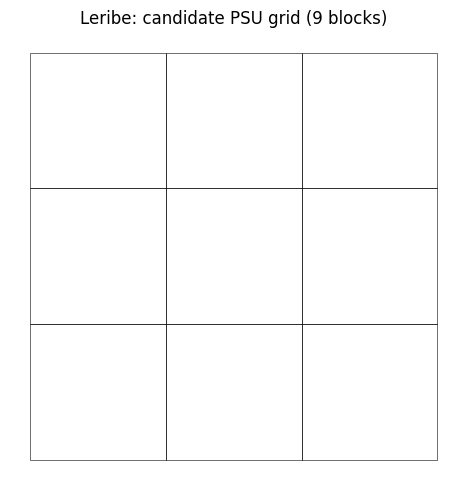

In [4]:
def build_frame(district_name):
    paths = DISTRICT_FILES[district_name]
    wheat_metric = reproject_raster(paths["wheat_raster"], GRID_CRS)
    grid = build_area_frame(wheat_metric, GRID_SIZE_M)
    grid = compute_wheat_intensity(grid, wheat_metric)
    grid = compute_slope_pct(grid, paths["slope"])
    return grid, wheat_metric

grid, wheat_metric = build_frame(DISTRICT)
print(f"{DISTRICT}: {len(grid)} candidate 2km x 2km blocks (PSUs) in the area frame")

fig, ax = plt.subplots(figsize=(6, 5))
grid.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.4)
ax.set_title(f"{DISTRICT}: candidate PSU grid ({len(grid)} blocks)")
ax.axis("off")
plt.tight_layout()
plt.show()


Not every block is usable, though. Some have almost no wheat; some are too steep for enumerators to
safely and efficiently survey. We filter those out before going further.


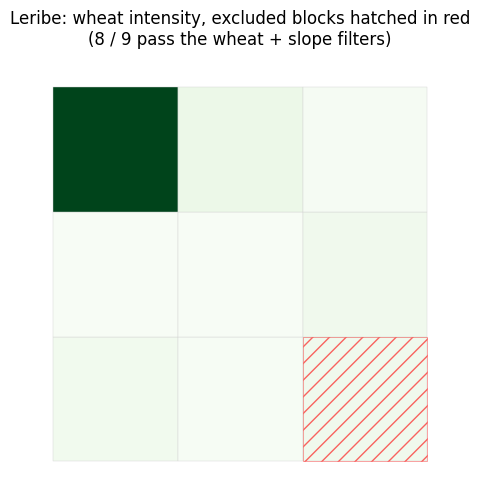

In [5]:
grid["is_viable_terrain"] = (
    (grid["wheat_intensity_pct"] >= MIN_WHEAT_INTENSITY_PCT) & (grid["mean_slope_pct"] <= MAX_SLOPE_PCT)
)

fig, ax = plt.subplots(figsize=(6, 5))
grid.plot(ax=ax, column="wheat_intensity_pct", cmap="Greens", edgecolor="lightgray", linewidth=0.3)
grid[~grid["is_viable_terrain"]].plot(ax=ax, facecolor="none", edgecolor="red", linewidth=0.4, hatch="//", alpha=0.6)
ax.set_title(f"{DISTRICT}: wheat intensity, excluded blocks hatched in red\n"
             f"({grid['is_viable_terrain'].sum()} / {len(grid)} pass the wheat + slope filters)")
ax.axis("off")
plt.tight_layout()
plt.show()


---
## 2. How do we divide the area?
### Stratification

Different parts of a district behave differently: some zones grow much more wheat than others, and the
terrain type (Lowlands, Foothills, Mountains, etc. -- the agro-ecological zone, or AEZ) affects both farming
patterns and how reliable the satellite classification is. Rather than treating the whole district as one
uniform population, we split it into **strata**: groups of blocks with similar wheat intensity *and* the
same AEZ. Each stratum will later get its own, independently-calculated sample size.


Leribe: 9 candidate blocks -> 8 viable, stratified blocks
    stratum_id  n_blocks
0  1_Foothills         2
1   1_Lowlands         2
2  2_Foothills         1
3   2_Lowlands         2
4   3_Lowlands         1


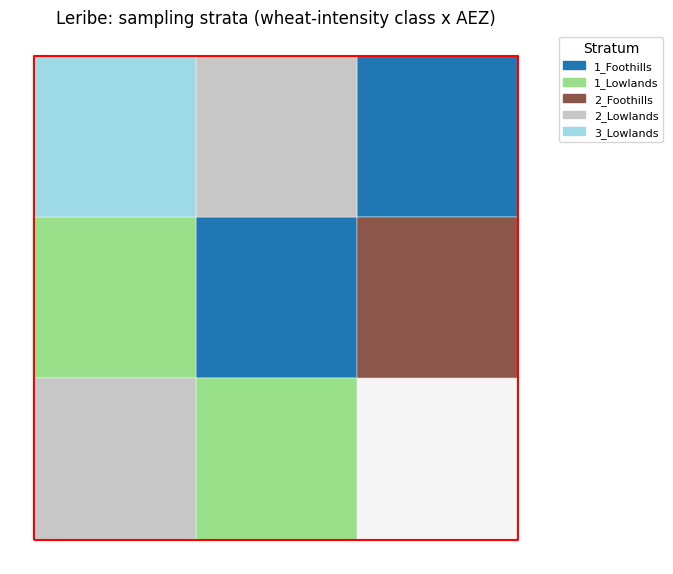

In [6]:
aez_gdf = load_aez_shapefile(AEZ_SHAPEFILE_PATH, GRID_CRS)
grid = assign_majority_aez(grid, aez_gdf, AEZ_FIELD)

grid_slope_ok = grid[grid["mean_slope_pct"] <= MAX_SLOPE_PCT].copy()
viable_blocks, breaks = stratify(grid_slope_ok, MIN_WHEAT_INTENSITY_PCT, N_INTENSITY_CLASSES)

boundary_gdf = gpd.read_file(DISTRICT_BOUNDARY_PATH)
if boundary_gdf.crs != GRID_CRS:
    boundary_gdf = boundary_gdf.to_crs(GRID_CRS)
district_boundary = boundary_gdf[boundary_gdf[DISTRICT_NAME_FIELD] == DISTRICT]

print(f"{DISTRICT}: {len(grid)} candidate blocks -> {len(viable_blocks)} viable, stratified blocks")
print(viable_blocks.groupby("stratum_id").size().rename("n_blocks").reset_index())

strata_ids = sorted(viable_blocks["stratum_id"].unique())
cmap = plt.get_cmap("tab20", len(strata_ids))
color_map = {sid: cmap(i) for i, sid in enumerate(strata_ids)}

fig, ax = plt.subplots(figsize=(7, 6))
grid.plot(ax=ax, facecolor="whitesmoke", edgecolor="lightgray", linewidth=0.3)
for sid, color in color_map.items():
    viable_blocks[viable_blocks["stratum_id"] == sid].plot(ax=ax, color=color, edgecolor="white", linewidth=0.3)
district_boundary.boundary.plot(ax=ax, color="red", linewidth=1.5)
legend_handles = [mpatches.Patch(color=c, label=s) for s, c in color_map.items()]
ax.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8, title="Stratum")
ax.set_title(f"{DISTRICT}: sampling strata (wheat-intensity class x AEZ)")
ax.axis("off")
plt.tight_layout()
plt.show()


---
## 3. Why can't we just sample anywhere?
### Wheat distribution is not uniform

The map above already makes this visible: wheat is concentrated in specific zones, not spread evenly across
the district. A sample that ignored this -- say, dropping points completely at random across the whole
district -- would waste most of its field visits in areas with almost no wheat, and would poorly represent
the areas that matter most. Stratification, plus the allocation step coming up, exists specifically to fix
this.


---
## 4. Why do we need S²between and S²within?
### *Interactive demonstration*

We're using a **two-stage** design: first we pick which PSUs (blocks) to visit, then which SSUs (fields)
inside them. To decide how to split our effort between "more blocks" and "more fields per block", we need
to understand how the satellite's predicted wheat likelihood *varies*:

- **Between PSUs:** are different 2x2 km blocks very different from each other?
- **Within PSUs:** are fields inside the *same* block very different from each other?

This matters because sampling 10 fields in one block does not give the same information as sampling 10
fields spread across 10 different blocks -- it depends on which kind of variability dominates.

**Move the slider below** to see how the picture changes as between-PSU variability increases, with
within-PSU variability held constant.


In [7]:
def plot_variability_demo(between_level):
    # between_level: 0 (low) to 1 (high). Within-PSU variability held fixed for comparison.
    rng = np.random.default_rng(7)
    n_psus = 4
    n_ssus_per_psu = 12
    within_std = 0.08

    psu_means = rng.normal(0.5, 0.03 + between_level * 0.30, n_psus)
    psu_means = np.clip(psu_means, 0.05, 0.95)

    fig, ax = plt.subplots(figsize=(8, 3.5))
    for i, mean in enumerate(psu_means):
        ssu_vals = np.clip(rng.normal(mean, within_std, n_ssus_per_psu), 0, 1)
        x = np.full(n_ssus_per_psu, i) + rng.uniform(-0.15, 0.15, n_ssus_per_psu)
        ax.scatter(x, ssu_vals, color="#3a7d44", alpha=0.7, s=40)
        ax.hlines(mean, i - 0.3, i + 0.3, color="black", linewidth=2)
    ax.set_xticks(range(n_psus))
    ax.set_xticklabels([f"PSU {i+1}" for i in range(n_psus)])
    ax.set_ylabel("Predicted wheat likelihood")
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"Between-PSU variability: {'Low' if between_level < 0.33 else 'Medium' if between_level < 0.66 else 'High'}"
                 f"  (black line = each PSU's average)")
    plt.tight_layout()
    plt.show()

    if between_level < 0.33:
        implication = ("PSUs look similar to each other -- visiting a new block teaches us little that\n"
                        "we didn't already know from the blocks we've already visited. The design leans\n"
                        "toward FEWER PSUs, each with MORE fields surveyed inside it.")
    elif between_level < 0.66:
        implication = ("A moderate mix -- the design balances PSU count and fields-per-PSU roughly evenly.")
    else:
        implication = ("PSUs are very different from one another -- a block's average tells us little about\n"
                        "its neighbour. The design leans toward MORE PSUs, each with FEWER fields surveyed\n"
                        "inside it, to make sure that diversity between blocks gets captured.")

    print("What happens to the sample design?\n")
    print(implication)


between_slider = FloatSlider(value=0.2, min=0.0, max=1.0, step=0.05,
                              description="Between-PSU\nvariability:", continuous_update=False,
                              style={"description_width": "120px"}, layout=widgets.Layout(width="400px"))
interact(plot_variability_demo, between_level=between_slider)


interactive(children=(FloatSlider(value=0.2, continuous_update=False, description='Between-PSU\nvariability:',…

<function __main__.plot_variability_demo(between_level)>

Your actual design doesn't guess at this -- it measures `S2_between` and `S2_within` directly from the
likelihood surface, per stratum, and uses the *real* values (not a slider) to size each stratum's clusters.
The next section builds that.


---
## 5. How much fieldwork can we afford?
### *Interactive demonstration* -- the cost ratio

Visiting a *new* block costs much more time than surveying one more field once a team is already there --
travel, finding the right entry point, briefing the local contact, and so on. Surveying an *additional*
field inside a block you're already in is comparatively quick. This asymmetry is captured as a **cost
ratio**: c1 (minutes to reach and set up in a new PSU) divided by c2 (minutes to survey one more SSU).

**Try changing c1 and c2 below** to see how the ratio -- and the balance it implies -- changes.


In [8]:
def show_cost_ratio(c1, c2):
    ratio = c1 / c2
    fig, ax = plt.subplots(figsize=(6, 2.2))
    ax.barh(["Reach a NEW PSU", "Survey ANOTHER SSU"], [c1, c2], color=["#c0392b", "#2e7d32"])
    ax.set_xlabel("Minutes")
    ax.set_title(f"Cost ratio c1/c2 = {c1:.0f}/{c2:.0f} = {ratio:.1f}")
    plt.tight_layout()
    plt.show()

    if ratio < 3:
        note = "Reaching a new block isn't much more expensive than surveying another field there.\nThe design can afford to spread out across MORE blocks."
    elif ratio < 8:
        note = "Reaching a new block costs noticeably more. The design starts favouring FEWER blocks\nwith more fields surveyed in each."
    else:
        note = ("Reaching a new block is MUCH more expensive than surveying another field there.\n"
                "The design strongly favours FEWER, larger blocks -- this is close to your real design's\n"
                "ratio of 90/10 = 9.")
    print(note)


c1_slider = IntSlider(value=90, min=10, max=150, step=5, description="c1 (min/PSU):",
                       continuous_update=False, style={"description_width": "110px"}, layout=widgets.Layout(width="400px"))
c2_slider = IntSlider(value=10, min=5, max=30, step=1, description="c2 (min/SSU):",
                       continuous_update=False, style={"description_width": "110px"}, layout=widgets.Layout(width="400px"))
interact(show_cost_ratio, c1=c1_slider, c2=c2_slider)


interactive(children=(IntSlider(value=90, continuous_update=False, description='c1 (min/PSU):', layout=Layout(…

<function __main__.show_cost_ratio(c1, c2)>

Because reaching a new PSU is much more expensive than surveying another field once the team is already
there, the optimal design needs to balance **statistical information** (Section 4) against **travel cost**
(this section). Your actual design uses `c1 = 90 min`, `c2 = 10 min` -> a ratio of **9** -- exactly what the
slider defaults to above.


---
## 6. How do we decide PSUs vs SSUs?
### Cochran's cost-based two-stage optimisation

We now have both pieces: how variability splits between and within blocks (Section 4), and how much more
expensive a new block is than an extra field (Section 5). Cochran's formula combines them into one number,
the **optimal cluster size** (`m`) -- how many fields to survey per selected block:

```
m_opt = sqrt( (c1 / c2) x (S2_within / S2_between) )
```

### *Interactive demonstration*

Suppose we have a fixed number of field observations to collect -- say, 100. We could do:

- 10 PSUs x 10 SSUs = 100
- 20 PSUs x 5 SSUs = 100
- 5 PSUs x 20 SSUs = 100

All three use the same fieldwork budget, but they do **not** give the same statistical precision -- it
depends on the real variance components. Try different splits below and see how the resulting precision
(lower is better) compares to Cochran's own optimal choice, marked with a dashed line.


In [9]:
def explore_psu_ssu_tradeoff(a_psus, S2_between=0.004, S2_within=0.028, total_budget=100, A_total=200):
    m_ssus = max(1, total_budget // a_psus)
    actual_n = a_psus * m_ssus

    # Same two-stage variance formula used in compute_achievable_cv(), with a simple finite
    # population correction against an illustrative total of A_total PSUs available.
    fpc = max(0, 1 - a_psus / A_total)
    var_estimate = (S2_between / a_psus) * fpc + S2_within / (a_psus * m_ssus)
    se = np.sqrt(var_estimate)

    # Cochran's own optimal choice, for comparison
    m_opt = compute_m_cochran(S2_between, S2_within, c1=90.0, c2=10.0)
    a_opt = max(1, round(total_budget / m_opt))
    fpc_opt = max(0, 1 - a_opt / A_total)
    var_opt = (S2_between / a_opt) * fpc_opt + S2_within / (a_opt * m_opt)
    se_opt = np.sqrt(var_opt)

    a_range = list(range(2, min(A_total, total_budget) + 1))
    se_curve = []
    for a in a_range:
        m = max(1, total_budget // a)
        fpc_a = max(0, 1 - a / A_total)
        v = (S2_between / a) * fpc_a + S2_within / (a * m)
        se_curve.append(np.sqrt(v))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(a_range, se_curve, color="#2e7d32", linewidth=2)
    ax.axvline(a_opt, color="black", linestyle="--", linewidth=1.2, label=f"Cochran optimum: a={a_opt}, m={m_opt}")
    ax.scatter([a_psus], [se], color="#c0392b", s=90, zorder=5, label=f"Your choice: a={a_psus}, m={m_ssus}")
    ax.set_xlabel("Number of PSUs (a)")
    ax.set_ylabel("Standard error of the estimate (lower = better)")
    ax.set_title(f"Your split: {a_psus} PSUs x {m_ssus} SSUs = {actual_n} field visits")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"Your choice's standard error:      {se:.4f}")
    print(f"Cochran-optimal standard error:    {se_opt:.4f}")
    if abs(a_psus - a_opt) <= 1:
        print("\nYou're at (or very near) the optimum!")
    elif a_psus < a_opt:
        print("\nToo few PSUs for this stratum's variability -- spreading out further would improve precision.")
    else:
        print("\nMore PSUs than needed here -- fields could be consolidated into fewer blocks without losing much precision, saving travel time.")


a_slider = IntSlider(value=10, min=2, max=50, step=1, description="Number of PSUs (a):",
                      continuous_update=False, style={"description_width": "150px"}, layout=widgets.Layout(width="420px"))
interact(explore_psu_ssu_tradeoff, a_psus=a_slider,
         S2_between=widgets.fixed(0.004), S2_within=widgets.fixed(0.028),
         total_budget=widgets.fixed(100), A_total=widgets.fixed(200))


interactive(children=(IntSlider(value=10, continuous_update=False, description='Number of PSUs (a):', layout=L…

<function __main__.explore_psu_ssu_tradeoff(a_psus, S2_between=0.004, S2_within=0.028, total_budget=100, A_total=200)>

These designs have the same number of field observations, but they don't provide the same statistical
information or require the same field effort. The optimisation chooses the combination that gives the best
balance given the real between-PSU variability, within-PSU variability, and the two costs -- exactly what
`optimize_two_stage_design()` computes for every stratum in the real design, reported next.


---
## 7. What does the final sample look like?

We now run the real allocation and optimisation on the actual district data: variance decomposition from
the likelihood surface, allocation of the district's fixed budget across strata, feasibility-checking, and
Cochran's optimisation for every stratum -- producing the actual PSUs and SSUs to be visited.


In [10]:
likelihood_metric = reproject_raster(DISTRICT_FILES[DISTRICT]["likelihood_raster"], GRID_CRS)
block_area_ha = (GRID_SIZE_M ** 2) / 10000
viable_blocks["area_ha"] = block_area_ha
viable_blocks["wheat_area_ha"] = viable_blocks["area_ha"] * viable_blocks["wheat_intensity_pct"] / 100

variance_results = []
for stratum in viable_blocks["stratum_id"].unique():
    blocks = viable_blocks[viable_blocks["stratum_id"] == stratum]
    psu_stats = compute_psu_pixel_statistics(blocks, likelihood_metric)
    variance = compute_variance_components(psu_stats)
    variance["stratum_id"] = stratum
    variance_results.append(variance)
variance_df = pd.DataFrame(variance_results)

strata_summary = (viable_blocks.groupby("stratum_id")
    .agg(n_blocks=("block_id", "count"), wheat_area_ha=("wheat_area_ha", "sum"),
         intensity_class=("intensity_class", "first"), aez_class=("aez_class", "first"))
    .reset_index())
strata_summary = strata_summary.merge(variance_df, on="stratum_id", how="left")
total_wheat = strata_summary["wheat_area_ha"].sum()
strata_summary["Wi"] = strata_summary["wheat_area_ha"] / total_wheat if total_wheat > 0 else 0

district_alloc = allocate_ssus(strata_summary, total_budget=DISTRICT_SSU_BUDGET[DISTRICT], method="optimal")
costs = C1_C2_BY_DISTRICT[DISTRICT]
district_alloc = enforce_feasibility_and_redistribute(district_alloc, costs)
district_alloc = apply_two_stage_optimization(district_alloc, costs)

print(f"{DISTRICT}: target budget {DISTRICT_SSU_BUDGET[DISTRICT]} -> achieved {district_alloc['n_ssu'].sum()} SSUs "
      f"across {district_alloc['a_opt'].sum()} PSUs")
print(district_alloc[["stratum_id", "n_blocks", "target_ssu", "a_opt", "m_opt", "n_ssu"]].to_string(index=False))

selected_psus, ssu_points, shortfall_df = select_psus_and_ssus(viable_blocks, district_alloc)


  Feasibility check: 521 SSUs redistributed within the district.
Leribe: target budget 612 -> achieved 90 SSUs across 6 PSUs
 stratum_id  n_blocks  target_ssu  a_opt  m_opt  n_ssu
1_Foothills         2          30      2     15     30
 1_Lowlands         2          30      2     15     30
2_Foothills         1           0      0      0      0
 2_Lowlands         2          30      2     15     30
 3_Lowlands         1           0      0      0      0


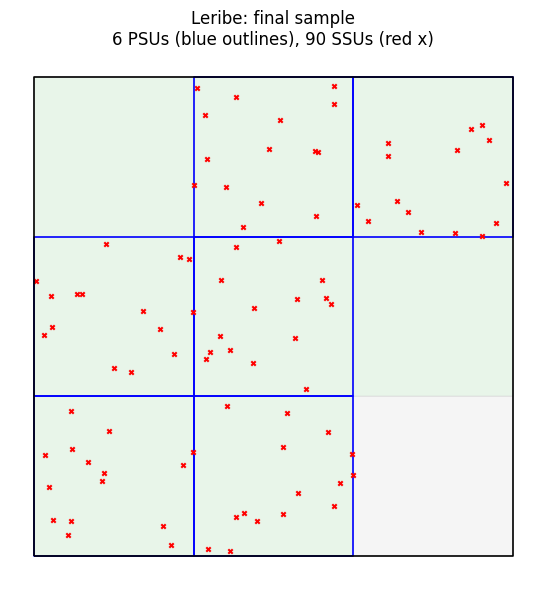

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
grid.plot(ax=ax, facecolor="whitesmoke", edgecolor="lightgray", linewidth=0.3)
viable_blocks.plot(ax=ax, facecolor="#e8f5e9", edgecolor="lightgray", linewidth=0.3)
selected_psus.plot(ax=ax, facecolor="none", edgecolor="blue", linewidth=1.2)
if len(ssu_points) > 0:
    ssu_points.plot(ax=ax, color="red", markersize=10, marker="x")
district_boundary.boundary.plot(ax=ax, color="black", linewidth=1.2)
ax.set_title(f"{DISTRICT}: final sample\n{len(selected_psus)} PSUs (blue outlines), {len(ssu_points)} SSUs (red x)")
ax.axis("off")
plt.tight_layout()
plt.show()


---
## 8. Is the design precise enough?

After deciding how many PSUs and SSUs to visit, we can estimate the expected precision of the survey
design using the coefficient of variation (**CV**) -- the relative uncertainty of the resulting wheat-area
estimate. Lower CV means a more precise estimate.


In [12]:
psus_available = viable_blocks.groupby("stratum_id").size()
stratum_cv = compute_achievable_cv(district_alloc, psus_available)
district_cv = compute_district_cv(stratum_cv, district_alloc)

print(f"{DISTRICT} achievable CV: {district_cv['district_cv']*100:.2f}%")

# The design document's reported values for all three districts, for reference
reported_cv = pd.DataFrame({
    "District": ["Leribe", "Mafeteng", "Berea"],
    "Achievable CV": ["1.00%", "1.09%", "1.23%"],
})
print("\nDesign document's reported values (all districts):")
print(reported_cv.to_string(index=False))
print("\nAll three are comfortably below the project's 2% precision target.")


Leribe achievable CV: 3.76%

Design document's reported values (all districts):
District Achievable CV
  Leribe         1.00%
Mafeteng         1.09%
   Berea         1.23%

All three are comfortably below the project's 2% precision target.


---
## 9. What does this mean for enumerators?

Everything above explains *why* the sample looks the way it does. In the field, the process collapses to a
simple sequence:

**Selected PSU (a block on the map) -> navigate to it -> locate the randomly generated SSU point inside it
-> that's the field to sample -> record the observation.**

Enumerators don't need to reproduce any of the statistics above -- but understanding *why* some zones have
many points and others have few, and why fields are grouped into blocks, helps make sense of an assignment
list that might otherwise look arbitrary. A stratum with zero points wasn't overlooked -- it didn't have
enough viable land or enough candidate blocks to sample reliably on its own, and its share of the workload
was safely redistributed to a neighbouring zone that could support it.
